---
## Section 1 — Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

#random seed for reproducibility
np.random.seed(42)

In [ ]:
def load_and_preprocess_data():
    print('Loading MNIST CSV files...')
    train_df = pd.read_csv('/kaggle/input/datasets/ftmjfr/mnistdataset/mnist_train.csv')
    test_df  = pd.read_csv('/kaggle/input/datasets/ftmjfr/mnistdataset/mnist_test.csv')

    # First column = label, rest = pixel values
    y_train = train_df.iloc[:, 0].values.astype(int)
    X_train = train_df.iloc[:, 1:].values.astype(float)

    y_test  = test_df.iloc[:, 0].values.astype(int)
    X_test  = test_df.iloc[:, 1:].values.astype(float)

    X_train = X_train / 255.0
    X_test  = X_test  / 255.0

    print(f'Training samples : {X_train.shape[0]}')
    print(f'Test samples     : {X_test.shape[0]}')
    print(f'Feature dimension: {X_train.shape[1]}  (28x28 pixels flattened)')
    return X_train, X_test, y_train, y_test


def one_hot_encode(y, num_classes=10):
    one_hot = np.zeros((len(y), num_classes))
    for i, label in enumerate(y):
        one_hot[i][label] = 1
    return one_hot


X_train, X_test, y_train, y_test = load_and_preprocess_data()

# Split 10% of training data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f'Validation samples: {X_val.shape[0]}')

Loading MNIST CSV files...
Training samples : 60000
Test samples     : 10000
Feature dimension: 784  (28x28 pixels flattened)
Validation samples: 6000


---
## Section 2 — Activation Functions

In [ ]:
class ActivationFunctions:
    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -500, 500)  # prevent numerical overflow
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def sigmoid_derivative(z):
        s = ActivationFunctions.sigmoid(z)
        return s * (1 - s)

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def relu_derivative(z):
        return (z > 0).astype(float)

    @staticmethod
    def tanh(z):
        return np.tanh(z)

    @staticmethod
    def tanh_derivative(z):
        return 1 - np.tanh(z) ** 2

    @staticmethod
    def softmax(z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    @staticmethod
    def get(name):
        funcs = {
            'sigmoid': (ActivationFunctions.sigmoid, ActivationFunctions.sigmoid_derivative),
            'relu'   : (ActivationFunctions.relu,    ActivationFunctions.relu_derivative),
            'tanh'   : (ActivationFunctions.tanh,    ActivationFunctions.tanh_derivative),
        }
        if name not in funcs:
            raise ValueError(f"Unsupported activation: '{name}'")
        return funcs[name]


---
## Section 3 — Loss Functions

In [ ]:
class LossFunctions:
    @staticmethod
    def cross_entropy(y_pred, y_true):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)  # prevent log(0)
        n = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred)) / n

    @staticmethod
    def cross_entropy_derivative(y_pred, y_true):
        return y_pred - y_true

    @staticmethod
    def mse(y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    @staticmethod
    def mse_derivative(y_pred, y_true):
        return 2 * (y_pred - y_true) / y_true.shape[0]


---
## Section 4 — Neural Network 


In [ ]:
class NeuralNetwork:
    
    def __init__(self, layer_sizes, activation='relu',
                 learning_rate=0.01, loss='cross_entropy'):
        self.layer_sizes     = layer_sizes
        self.learning_rate   = learning_rate
        self.loss_name       = loss
        self.activation_name = activation
        self.num_layers      = len(layer_sizes)

        self.activation_func, self.activation_deriv = ActivationFunctions.get(activation)

        if loss == 'cross_entropy':
            self.loss_func  = LossFunctions.cross_entropy
            self.loss_deriv = LossFunctions.cross_entropy_derivative
        elif loss == 'mse':
            self.loss_func  = LossFunctions.mse
            self.loss_deriv = LossFunctions.mse_derivative
        else:
            raise ValueError(f"Unsupported loss: '{loss}'")

        self._initialize_weights()

        # Training history
        self.train_losses      = []
        self.train_accuracies  = []
        self.val_losses        = []
        self.val_accuracies    = []

    # ------------------------------------------------------------------
    def _initialize_weights(self):
        self.weights = []
        self.biases  = []
        for i in range(self.num_layers - 1):
            fan_in  = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]
            scale = np.sqrt(2.0 / fan_in) if self.activation_name == 'relu' \
                    else np.sqrt(1.0 / fan_in)
            self.weights.append(np.random.randn(fan_in, fan_out) * scale)
            self.biases.append(np.zeros((1, fan_out)))

    # ------------------------------------------------------------------
    def forward(self, X):
        self.activations = [X]
        self.z_values    = []
        current = X

        for i in range(self.num_layers - 2):
            z = current @ self.weights[i] + self.biases[i]
            self.z_values.append(z)
            a = self.activation_func(z)
            self.activations.append(a)
            current = a

        # Output layer — Softmax
        z_out = current @ self.weights[-1] + self.biases[-1]
        self.z_values.append(z_out)
        output = ActivationFunctions.softmax(z_out)
        self.activations.append(output)
        return output

    # ------------------------------------------------------------------
    def backward(self, X, y_true):
        n           = X.shape[0]
        y_pred      = self.activations[-1]
        delta       = self.loss_deriv(y_pred, y_true)   # output layer delta

        grad_weights = [None] * len(self.weights)
        grad_biases  = [None] * len(self.biases)

        for i in reversed(range(len(self.weights))):
            grad_weights[i] = self.activations[i].T @ delta / n
            grad_biases[i]  = np.sum(delta, axis=0, keepdims=True) / n
            if i > 0:
                # propagate delta to previous layer
                delta = (delta @ self.weights[i].T) * \
                        self.activation_deriv(self.z_values[i - 1])

        return grad_weights, grad_biases

    # ------------------------------------------------------------------
    def update_weights(self, grad_weights, grad_biases):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * grad_weights[i]
            self.biases[i]  -= self.learning_rate * grad_biases[i]

    # ------------------------------------------------------------------
    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def compute_accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    # ------------------------------------------------------------------
    def train(self, X_train, y_train, X_val, y_val,
              epochs=50, batch_size=64, verbose=True,
              early_stopping_patience=10):
       
        y_train_oh   = one_hot_encode(y_train)
        n            = X_train.shape[0]
        best_val     = np.inf
        patience_cnt = 0
        best_W = best_b = None

        print(f"\n{'='*60}")
        print(f"Architecture : {self.layer_sizes}")
        print(f"Activation   : {self.activation_name}  |  LR: {self.learning_rate}")
        print(f"Batch size   : {batch_size}  |  Epochs: {epochs}")
        print(f"{'='*60}\n")

        for epoch in range(epochs):
            idx       = np.random.permutation(n)
            X_shuf    = X_train[idx]
            y_shuf    = y_train_oh[idx]
            ep_loss   = 0
            n_batches = 0

            for start in range(0, n, batch_size):
                Xb = X_shuf[start:start + batch_size]
                yb = y_shuf[start:start + batch_size]
                pred = self.forward(Xb)
                ep_loss += self.loss_func(pred, yb)
                n_batches += 1
                gw, gb = self.backward(Xb, yb)
                self.update_weights(gw, gb)

            avg_loss  = ep_loss / n_batches
            train_acc = self.compute_accuracy(X_train, y_train)
            val_pred  = self.forward(X_val)
            val_loss  = self.loss_func(val_pred, one_hot_encode(y_val))
            val_acc   = self.compute_accuracy(X_val, y_val)

            self.train_losses.append(avg_loss)
            self.train_accuracies.append(train_acc)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)

            if verbose and (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1:3d}/{epochs} | "
                      f"Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

            # Early Stopping check
            if val_loss < best_val:
                best_val     = val_loss
                patience_cnt = 0
                best_W = [w.copy() for w in self.weights]
                best_b = [b.copy() for b in self.biases]
            else:
                patience_cnt += 1
                if patience_cnt >= early_stopping_patience:
                    print(f"\nEarly stopping triggered at epoch {epoch+1}.")
                    self.weights = best_W
                    self.biases  = best_b
                    break

        print("Training complete.")

    # ------------------------------------------------------------------
    def save_weights(self, filename='model_weights.npz'):
        save_dict = {}
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            save_dict[f'W{i}'] = w
            save_dict[f'b{i}'] = b
        np.savez(filename, **save_dict)
        print(f"Weights saved to '{filename}'.")

    def load_weights(self, filename='model_weights.npz'):
        """Load weights and biases from a .npz file."""
        data = np.load(filename)
        self.weights = [data[f'W{i}'] for i in range(len(self.weights))]
        self.biases  = [data[f'b{i}'] for i in range(len(self.biases))]
        print(f"Weights loaded from '{filename}'.")


---
## Section 5 — Adam Optimizer (Bonus 5)


In [ ]:
class NeuralNetworkAdam(NeuralNetwork):
    def __init__(self, layer_sizes, activation='relu', learning_rate=0.001,
                 loss='cross_entropy', beta1=0.9, beta2=0.999, epsilon=1e-8):
        super().__init__(layer_sizes, activation, learning_rate, loss)
        self.beta1   = beta1
        self.beta2   = beta2
        self.epsilon = epsilon
        self.t       = 0
        # First and second moment vectors
        self.m_w = [np.zeros_like(w) for w in self.weights]
        self.v_w = [np.zeros_like(w) for w in self.weights]
        self.m_b = [np.zeros_like(b) for b in self.biases]
        self.v_b = [np.zeros_like(b) for b in self.biases]

    def update_weights(self, grad_weights, grad_biases):
        """Adam parameter update"""
        self.t += 1
        for i in range(len(self.weights)):
            # Update biased first moment
            self.m_w[i] = self.beta1 * self.m_w[i] + (1 - self.beta1) * grad_weights[i]
            self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * grad_biases[i]
            # Update biased second moment
            self.v_w[i] = self.beta2 * self.v_w[i] + (1 - self.beta2) * grad_weights[i]**2
            self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * grad_biases[i]**2
            # Bias-corrected estimates
            mw_hat = self.m_w[i] / (1 - self.beta1**self.t)
            mb_hat = self.m_b[i] / (1 - self.beta1**self.t)
            vw_hat = self.v_w[i] / (1 - self.beta2**self.t)
            vb_hat = self.v_b[i] / (1 - self.beta2**self.t)
            # Update parameters
            self.weights[i] -= self.learning_rate * mw_hat / (np.sqrt(vw_hat) + self.epsilon)
            self.biases[i]  -= self.learning_rate * mb_hat / (np.sqrt(vb_hat) + self.epsilon)


---
## Section 6 — Dropout Regularization (Bonus 2)


In [ ]:
class NeuralNetworkDropout(NeuralNetwork):

    def __init__(self, layer_sizes, activation='relu', learning_rate=0.01,
                 loss='cross_entropy', dropout_rate=0.5):
        super().__init__(layer_sizes, activation, learning_rate, loss)
        self.dropout_rate  = dropout_rate
        self.training_mode = True

    def forward(self, X):
        self.activations    = [X]
        self.z_values       = []
        self.dropout_masks  = []
        current = X

        for i in range(self.num_layers - 2):
            z = current @ self.weights[i] + self.biases[i]
            self.z_values.append(z)
            a = self.activation_func(z)

            if self.training_mode:
                # Inverted dropout: zero out neurons and scale survivors
                mask = (np.random.rand(*a.shape) > self.dropout_rate) / (1 - self.dropout_rate)
                a = a * mask
                self.dropout_masks.append(mask)
            else:
                self.dropout_masks.append(None)

            self.activations.append(a)
            current = a

        z_out  = current @ self.weights[-1] + self.biases[-1]
        self.z_values.append(z_out)
        output = ActivationFunctions.softmax(z_out)
        self.activations.append(output)
        return output

    def backward(self, X, y_true):
        n      = X.shape[0]
        y_pred = self.activations[-1]
        delta  = self.loss_deriv(y_pred, y_true)
        grad_weights = [None] * len(self.weights)
        grad_biases  = [None] * len(self.biases)

        for i in reversed(range(len(self.weights))):
            grad_weights[i] = self.activations[i].T @ delta / n
            grad_biases[i]  = np.sum(delta, axis=0, keepdims=True) / n
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.activation_deriv(self.z_values[i - 1])
                if self.dropout_masks[i - 1] is not None:
                    delta = delta * self.dropout_masks[i - 1]
        return grad_weights, grad_biases

    def predict(self, X):
        self.training_mode = False
        result = super().predict(X)
        self.training_mode = True
        return result

    def compute_accuracy(self, X, y):
        self.training_mode = False
        result = super().compute_accuracy(X, y)
        self.training_mode = True
        return result


---
## Section 7 — Visualization & Analysis 

In [ ]:
def plot_training_history(model, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {title}', fontsize=14, fontweight='bold')
    epochs = range(1, len(model.train_losses) + 1)

    axes[0].plot(epochs, model.train_losses, 'b-',  label='Train Loss',      linewidth=2)
    axes[0].plot(epochs, model.val_losses,   'r--', label='Validation Loss', linewidth=2)
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, model.train_accuracies, 'b-',  label='Train Accuracy',      linewidth=2)
    axes[1].plot(epochs, model.val_accuracies,   'r--', label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig(f'training_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(model, X_test, y_test, title=''):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nPer-class accuracy ({title}):')
    print(f'{"Digit":>6} | {"Accuracy":>8} | {"Wrong":>8}')
    print('-' * 30)
    for i in range(10):
        total   = cm[i].sum()
        correct = cm[i][i]
        print(f'{i:6d} | {correct/total:8.4f} | {total-correct:8d}')
    return cm


def plot_misclassified(model, X_test, y_test, num_samples=16):
    y_pred    = model.predict(X_test)
    wrong_idx = np.where(y_pred != y_test)[0]

    if len(wrong_idx) == 0:
        print('No misclassified samples!')
        return

    selected = np.random.choice(wrong_idx, min(num_samples, len(wrong_idx)), replace=False)
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Misclassified Samples', fontsize=14, fontweight='bold')

    for idx, ax in enumerate(axes.flat):
        if idx < len(selected):
            i = selected[idx]
            ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
            ax.set_title(f'True: {y_test[i]}  Pred: {y_pred[i]}', color='red', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('misclassified.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nTop-10 most common error pairs (True → Predicted):')
    error_pairs = Counter((y_test[i], y_pred[i]) for i in wrong_idx)
    for (true, pred), cnt in error_pairs.most_common(10):
        print(f'  {true} → {pred} : {cnt} times')


def compare_architectures(results):
    names     = list(results.keys())
    test_accs = [results[n]['test_acc']  for n in names]
    train_accs= [results[n]['train_acc'] for n in names]
    x     = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 6))
    b1 = ax.bar(x - width/2, train_accs, width, label='Train Acc', color='steelblue', alpha=0.85)
    b2 = ax.bar(x + width/2, test_accs,  width, label='Test Acc',  color='coral',     alpha=0.85)
    ax.set_title('Architecture Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0.5, 1.0])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig('arch_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Section 8 — Model Training (2 Hidden Layers, ReLU, Adam)

In [9]:
print('='*70)
print('Training Main Model: [784 -> 256 -> 128 -> 10], ReLU, Adam')
print('='*70)

main_model = NeuralNetworkAdam(
    layer_sizes=[784, 256, 128, 10],
    activation='relu',
    learning_rate=0.001
)

main_model.train(
    X_train, y_train,
    X_val,   y_val,
    epochs=50,
    batch_size=64,
    verbose=True,
    early_stopping_patience=8
)

train_acc = main_model.compute_accuracy(X_train, y_train)
test_acc  = main_model.compute_accuracy(X_test,  y_test)
print(f'\nFinal Results:')
print(f'  Train Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'  Test  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Training Main Model: [784 -> 256 -> 128 -> 10], ReLU, Adam

Architecture : [784, 256, 128, 10]
Activation   : relu  |  LR: 0.001
Batch size   : 64  |  Epochs: 50

Epoch   5/50 | Train Loss: 0.0346 | Train Acc: 0.9924 | Val Loss: 0.0880 | Val Acc: 0.9760
Epoch  10/50 | Train Loss: 0.0160 | Train Acc: 0.9958 | Val Loss: 0.0979 | Val Acc: 0.9763

Early stopping triggered at epoch 14.
Training complete.

Final Results:
  Train Accuracy : 0.9936  (99.36%)
  Test  Accuracy : 0.9769  (97.69%)


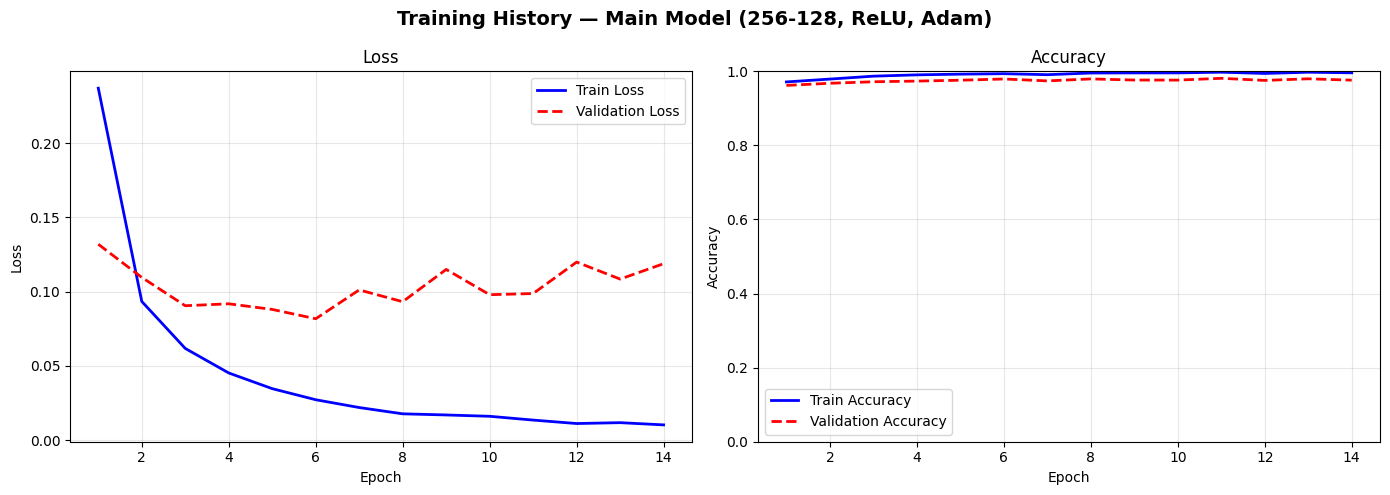

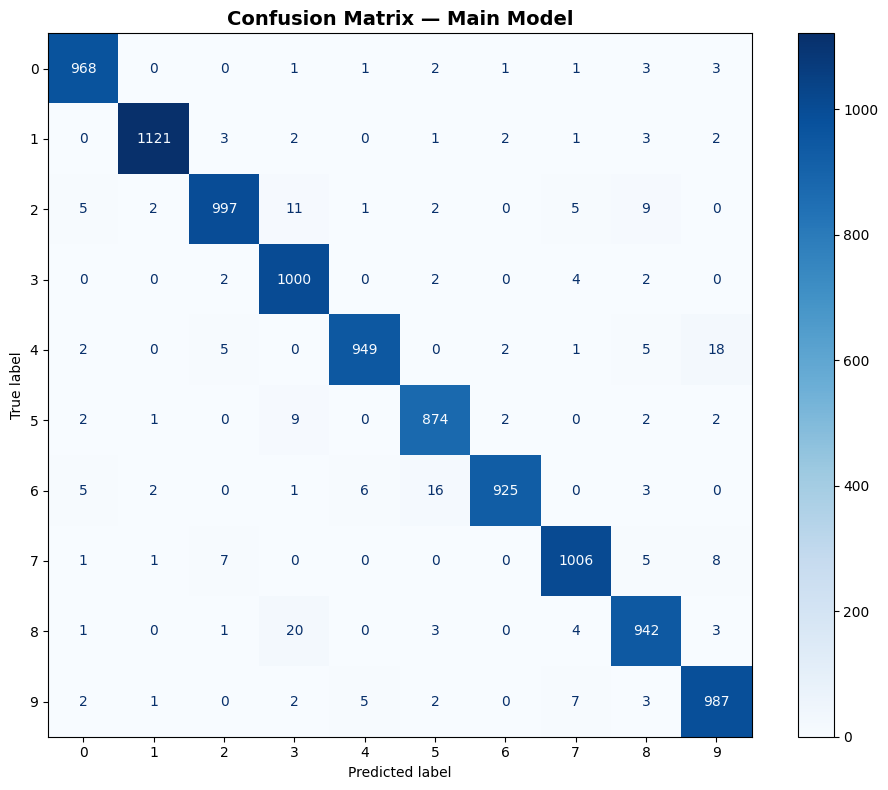


Per-class accuracy (Main Model):
 Digit | Accuracy |    Wrong
------------------------------
     0 |   0.9878 |       12
     1 |   0.9877 |       14
     2 |   0.9661 |       35
     3 |   0.9901 |       10
     4 |   0.9664 |       33
     5 |   0.9798 |       18
     6 |   0.9656 |       33
     7 |   0.9786 |       22
     8 |   0.9671 |       32
     9 |   0.9782 |       22


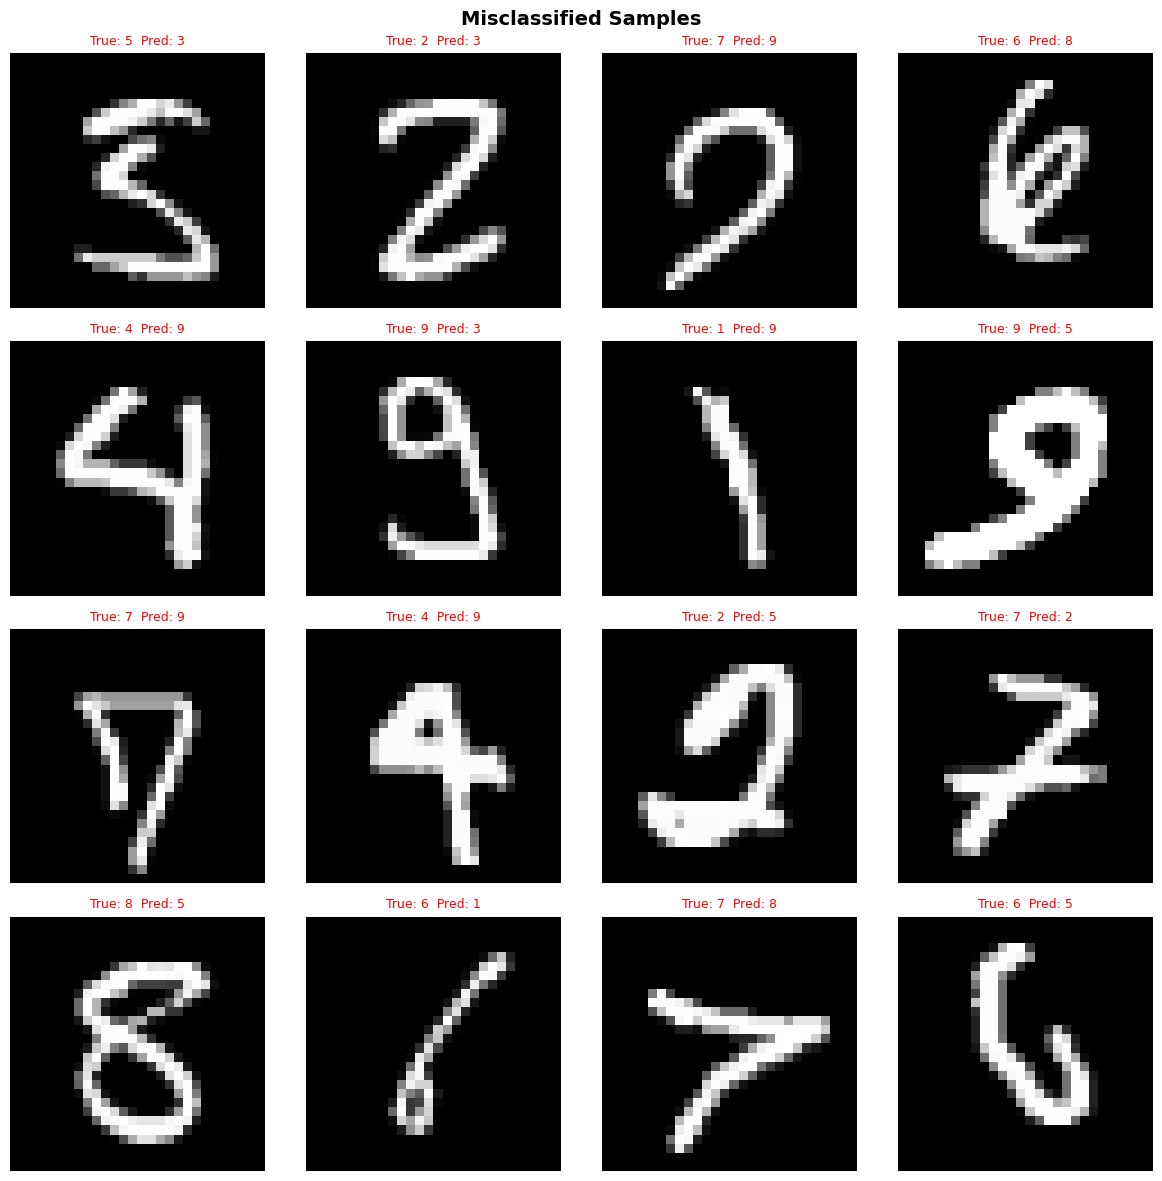


Top-10 most common error pairs (True → Predicted):
  8 → 3 : 20 times
  4 → 9 : 18 times
  6 → 5 : 16 times
  2 → 3 : 11 times
  5 → 3 : 9 times
  2 → 8 : 9 times
  7 → 9 : 8 times
  9 → 7 : 7 times
  7 → 2 : 7 times
  6 → 4 : 6 times
Weights saved to 'best_model_weights.npz'.


In [10]:
# Plot training curves
plot_training_history(main_model, 'Main Model (256-128, ReLU, Adam)')

# Confusion matrix
plot_confusion_matrix(main_model, X_test, y_test, 'Main Model')

# Show misclassified examples
plot_misclassified(main_model, X_test, y_test)

# Save weights (Bonus 3)
main_model.save_weights('best_model_weights.npz')

---
## Section 9 — Architecture Comparison 

Comparing different architectures...

Architecture : [784, 128, 10]
Activation   : relu  |  LR: 0.001
Batch size   : 64  |  Epochs: 20


Early stopping triggered at epoch 17.
Training complete.
1 Hidden (128)                 | Train: 0.9977 | Test: 0.9679

Architecture : [784, 256, 128, 10]
Activation   : relu  |  LR: 0.001
Batch size   : 64  |  Epochs: 20


Early stopping triggered at epoch 10.
Training complete.
2 Hidden (256-128)             | Train: 0.9948 | Test: 0.9680

Architecture : [784, 256, 128, 10]
Activation   : sigmoid  |  LR: 0.001
Batch size   : 64  |  Epochs: 20

Training complete.
2 Hidden (Sigmoid)             | Train: 0.9996 | Test: 0.9692

Architecture : [784, 256, 128, 10]
Activation   : tanh  |  LR: 0.001
Batch size   : 64  |  Epochs: 20

Training complete.
2 Hidden (Tanh)                | Train: 1.0000 | Test: 0.9704

Architecture : [784, 32, 10]
Activation   : relu  |  LR: 0.001
Batch size   : 64  |  Epochs: 20

Training complete.
Few Neurons (32)              

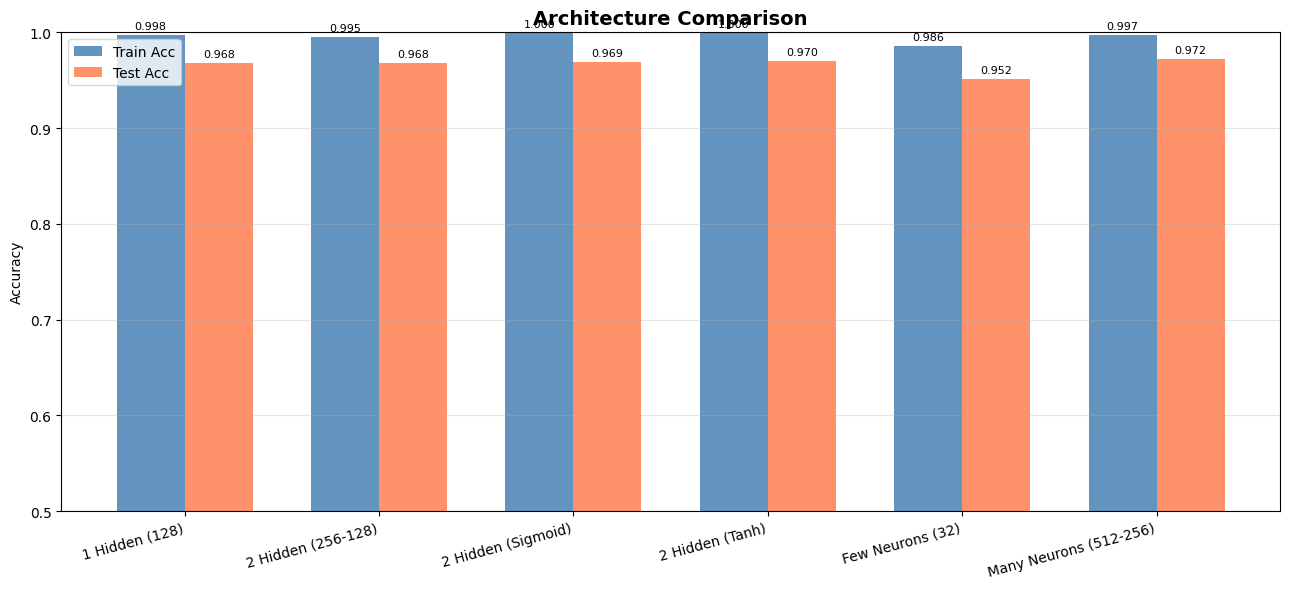

In [11]:
print('Comparing different architectures...')

architectures = {}
configs = [
    {'name': '1 Hidden (128)',      'layers': [784, 128, 10],       'act': 'relu'},
    {'name': '2 Hidden (256-128)',  'layers': [784, 256, 128, 10],  'act': 'relu'},
    {'name': '2 Hidden (Sigmoid)',  'layers': [784, 256, 128, 10],  'act': 'sigmoid'},
    {'name': '2 Hidden (Tanh)',     'layers': [784, 256, 128, 10],  'act': 'tanh'},
    {'name': 'Few Neurons (32)',    'layers': [784, 32, 10],         'act': 'relu'},
    {'name': 'Many Neurons (512-256)', 'layers': [784, 512, 256, 10], 'act': 'relu'},
]

for cfg in configs:
    model = NeuralNetworkAdam(
        layer_sizes=cfg['layers'],
        activation=cfg['act'],
        learning_rate=0.001
    )
    model.train(X_train[:20000], y_train[:20000], X_val, y_val,
                epochs=20, batch_size=64, verbose=False, early_stopping_patience=5)
    t_acc  = model.compute_accuracy(X_train[:20000], y_train[:20000])
    te_acc = model.compute_accuracy(X_test, y_test)
    architectures[cfg['name']] = {'train_acc': t_acc, 'test_acc': te_acc}
    print(f"{cfg['name']:30s} | Train: {t_acc:.4f} | Test: {te_acc:.4f}")

compare_architectures(architectures)

---
## Section 10 — Dropout Model (Bonus 2)

Training model with Dropout (rate=0.3)...

Architecture : [784, 256, 128, 10]
Activation   : relu  |  LR: 0.01
Batch size   : 64  |  Epochs: 30

Epoch   5/30 | Train Loss: 0.5107 | Train Acc: 0.9050 | Val Loss: 0.5007 | Val Acc: 0.9002
Epoch  10/30 | Train Loss: 0.3694 | Train Acc: 0.9263 | Val Loss: 0.3869 | Val Acc: 0.9227
Epoch  15/30 | Train Loss: 0.3094 | Train Acc: 0.9383 | Val Loss: 0.3433 | Val Acc: 0.9315
Epoch  20/30 | Train Loss: 0.2664 | Train Acc: 0.9472 | Val Loss: 0.2833 | Val Acc: 0.9375
Epoch  25/30 | Train Loss: 0.2322 | Train Acc: 0.9550 | Val Loss: 0.2821 | Val Acc: 0.9435
Epoch  30/30 | Train Loss: 0.2121 | Train Acc: 0.9607 | Val Loss: 0.2535 | Val Acc: 0.9468
Training complete.
Dropout Model — Test Accuracy: 0.9504  (95.04%)


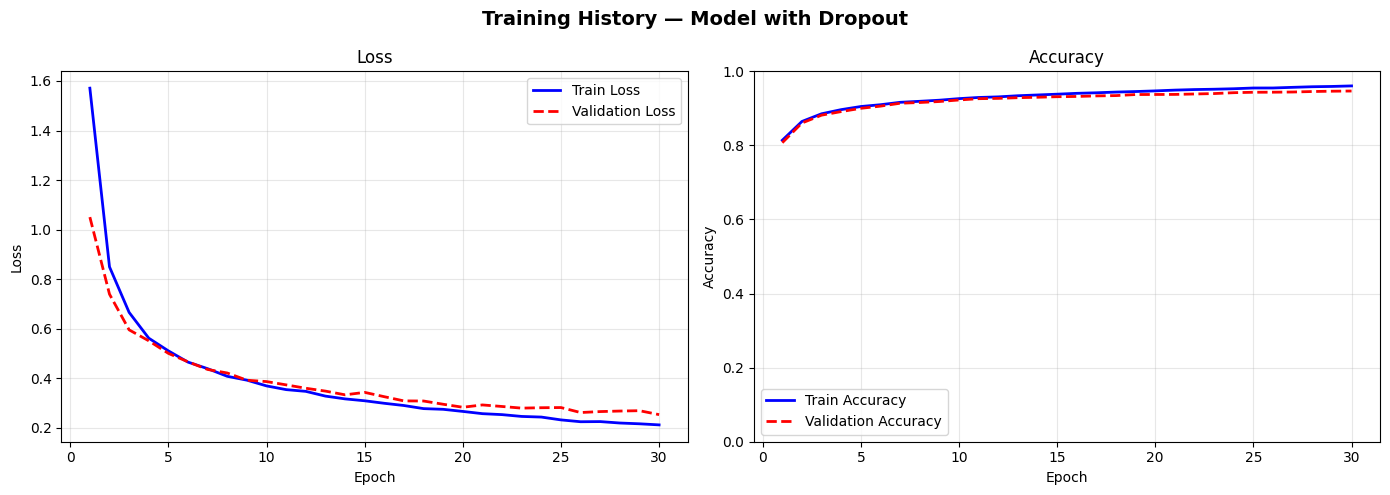

In [12]:
print('Training model with Dropout (rate=0.3)...')

dropout_model = NeuralNetworkDropout(
    layer_sizes=[784, 256, 128, 10],
    activation='relu',
    learning_rate=0.01,
    dropout_rate=0.3
)
dropout_model.train(X_train[:20000], y_train[:20000], X_val, y_val,
                    epochs=30, batch_size=64, verbose=True, early_stopping_patience=7)

dropout_acc = dropout_model.compute_accuracy(X_test, y_test)
print(f'Dropout Model — Test Accuracy: {dropout_acc:.4f}  ({dropout_acc*100:.2f}%)')
plot_training_history(dropout_model, 'Model with Dropout')

---
## Section 11 — Hyperparameter Analysis

In [13]:
print('\n' + '='*60)
print('Hyperparameter Analysis')
print('='*60)

# --- 1. Effect of Learning Rate ---
print('\n1. Effect of Learning Rate:')
lr_results = {}
for lr in [0.0001, 0.001, 0.01, 0.1]:
    m = NeuralNetworkAdam([784, 128, 64, 10], activation='relu', learning_rate=lr)
    m.train(X_train[:10000], y_train[:10000], X_val, y_val,
            epochs=15, batch_size=64, verbose=False, early_stopping_patience=5)
    acc = m.compute_accuracy(X_test, y_test)
    lr_results[lr] = acc
    print(f'  LR={lr:.4f}  ->  Test Acc: {acc:.4f}')

# --- 2. Effect of Number of Neurons ---
print('\n2. Effect of Number of Hidden Neurons:')
neuron_results = {}
for neurons in [16, 64, 128, 256, 512]:
    m = NeuralNetworkAdam([784, neurons, 10], activation='relu', learning_rate=0.001)
    m.train(X_train[:10000], y_train[:10000], X_val, y_val,
            epochs=15, batch_size=64, verbose=False, early_stopping_patience=5)
    acc = m.compute_accuracy(X_test, y_test)
    neuron_results[neurons] = acc
    print(f'  {neurons:4d} neurons  ->  Test Acc: {acc:.4f}')

# --- 3. Effect of Activation Function ---
print('\n3. Effect of Activation Function:')
act_results = {}
for act in ['relu', 'sigmoid', 'tanh']:
    m = NeuralNetworkAdam([784, 128, 64, 10], activation=act, learning_rate=0.001)
    m.train(X_train[:10000], y_train[:10000], X_val, y_val,
            epochs=15, batch_size=64, verbose=False, early_stopping_patience=5)
    acc = m.compute_accuracy(X_test, y_test)
    act_results[act] = acc
    print(f'  {act:10s}  ->  Test Acc: {acc:.4f}')

# --- 4. Effect of Batch Size ---
print('\n4. Effect of Batch Size:')
batch_results = {}
for bs in [16, 64, 256, 1024]:
    m = NeuralNetworkAdam([784, 128, 64, 10], activation='relu', learning_rate=0.001)
    m.train(X_train[:10000], y_train[:10000], X_val, y_val,
            epochs=15, batch_size=bs, verbose=False, early_stopping_patience=5)
    acc = m.compute_accuracy(X_test, y_test)
    batch_results[bs] = acc
    print(f'  Batch={bs:5d}  ->  Test Acc: {acc:.4f}')


Hyperparameter Analysis

1. Effect of Learning Rate:

Architecture : [784, 128, 64, 10]
Activation   : relu  |  LR: 0.0001
Batch size   : 64  |  Epochs: 15

Training complete.
  LR=0.0001  ->  Test Acc: 0.9319

Architecture : [784, 128, 64, 10]
Activation   : relu  |  LR: 0.001
Batch size   : 64  |  Epochs: 15


Early stopping triggered at epoch 13.
Training complete.
  LR=0.0010  ->  Test Acc: 0.9549

Architecture : [784, 128, 64, 10]
Activation   : relu  |  LR: 0.01
Batch size   : 64  |  Epochs: 15


Early stopping triggered at epoch 7.
Training complete.
  LR=0.0100  ->  Test Acc: 0.9446

Architecture : [784, 128, 64, 10]
Activation   : relu  |  LR: 0.1
Batch size   : 64  |  Epochs: 15


Early stopping triggered at epoch 11.
Training complete.
  LR=0.1000  ->  Test Acc: 0.8474

2. Effect of Number of Hidden Neurons:

Architecture : [784, 16, 10]
Activation   : relu  |  LR: 0.001
Batch size   : 64  |  Epochs: 15

Training complete.
    16 neurons  ->  Test Acc: 0.9271

Architecture 

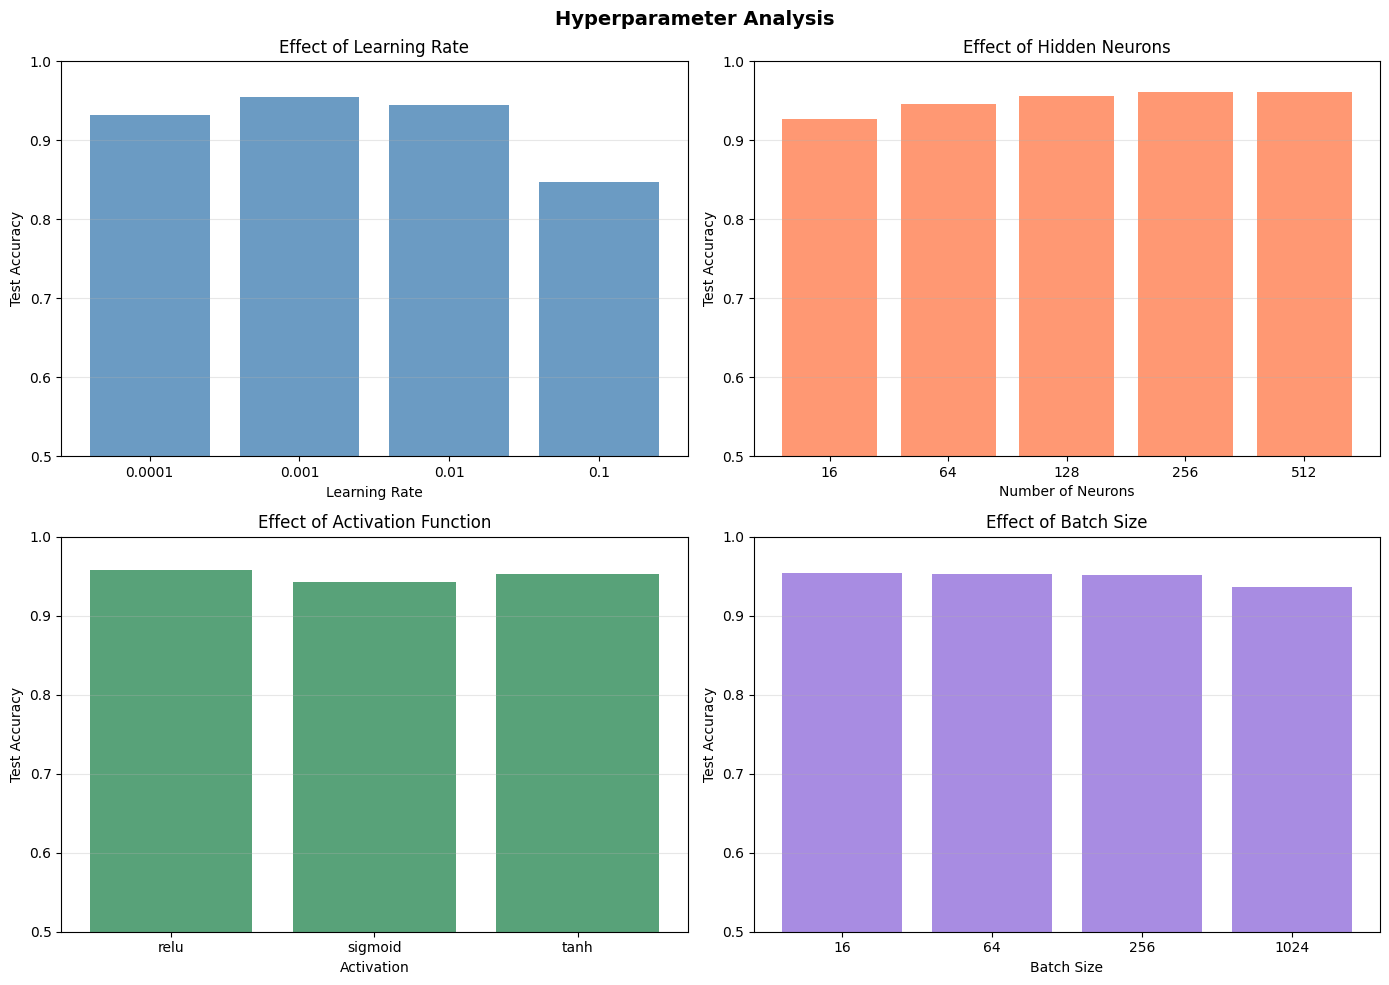

In [14]:
# Visualize hyperparameter results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hyperparameter Analysis', fontsize=14, fontweight='bold')

# Learning Rate
axes[0,0].bar([str(lr) for lr in lr_results.keys()], lr_results.values(), color='steelblue', alpha=0.8)
axes[0,0].set_title('Effect of Learning Rate')
axes[0,0].set_xlabel('Learning Rate')
axes[0,0].set_ylabel('Test Accuracy')
axes[0,0].set_ylim([0.5, 1.0])
axes[0,0].grid(True, alpha=0.3, axis='y')

# Neurons
axes[0,1].bar([str(n) for n in neuron_results.keys()], neuron_results.values(), color='coral', alpha=0.8)
axes[0,1].set_title('Effect of Hidden Neurons')
axes[0,1].set_xlabel('Number of Neurons')
axes[0,1].set_ylabel('Test Accuracy')
axes[0,1].set_ylim([0.5, 1.0])
axes[0,1].grid(True, alpha=0.3, axis='y')

# Activation
axes[1,0].bar(act_results.keys(), act_results.values(), color='seagreen', alpha=0.8)
axes[1,0].set_title('Effect of Activation Function')
axes[1,0].set_xlabel('Activation')
axes[1,0].set_ylabel('Test Accuracy')
axes[1,0].set_ylim([0.5, 1.0])
axes[1,0].grid(True, alpha=0.3, axis='y')

# Batch Size
axes[1,1].bar([str(bs) for bs in batch_results.keys()], batch_results.values(), color='mediumpurple', alpha=0.8)
axes[1,1].set_title('Effect of Batch Size')
axes[1,1].set_xlabel('Batch Size')
axes[1,1].set_ylabel('Test Accuracy')
axes[1,1].set_ylim([0.5, 1.0])
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hyperparameter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 12 — Adam vs SGD Comparison (Bonus 5)

Adam vs SGD comparison...

Architecture : [784, 128, 64, 10]
Activation   : relu  |  LR: 0.01
Batch size   : 64  |  Epochs: 30

Training complete.

Architecture : [784, 128, 64, 10]
Activation   : relu  |  LR: 0.001
Batch size   : 64  |  Epochs: 30


Early stopping triggered at epoch 14.
Training complete.
SGD  Test Accuracy : 0.9474
Adam Test Accuracy : 0.9658


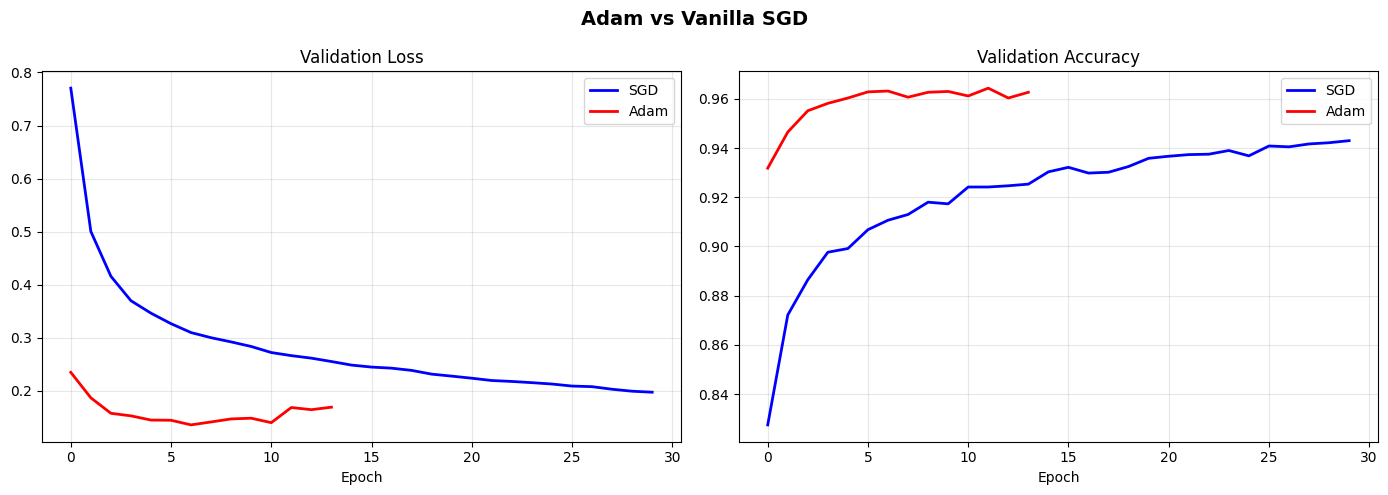

In [15]:
print('Adam vs SGD comparison...')

sgd_model = NeuralNetwork(
    layer_sizes=[784, 128, 64, 10], activation='relu', learning_rate=0.01
)
sgd_model.train(X_train[:20000], y_train[:20000], X_val, y_val,
                epochs=30, batch_size=64, verbose=False, early_stopping_patience=7)
sgd_acc = sgd_model.compute_accuracy(X_test, y_test)

adam_cmp = NeuralNetworkAdam(
    layer_sizes=[784, 128, 64, 10], activation='relu', learning_rate=0.001
)
adam_cmp.train(X_train[:20000], y_train[:20000], X_val, y_val,
               epochs=30, batch_size=64, verbose=False, early_stopping_patience=7)
adam_acc = adam_cmp.compute_accuracy(X_test, y_test)

print(f'SGD  Test Accuracy : {sgd_acc:.4f}')
print(f'Adam Test Accuracy : {adam_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Adam vs Vanilla SGD', fontsize=14, fontweight='bold')

axes[0].plot(sgd_model.val_losses,  'b-', label='SGD',  linewidth=2)
axes[0].plot(adam_cmp.val_losses,   'r-', label='Adam', linewidth=2)
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sgd_model.val_accuracies, 'b-', label='SGD',  linewidth=2)
axes[1].plot(adam_cmp.val_accuracies,  'r-', label='Adam', linewidth=2)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 13 — Final Summary

In [17]:
print('\n' + '='*70)
print('FINAL SUMMARY')
print('='*70)
print(f'Main Model [784 -> 256 -> 128 -> 10], ReLU, Adam:')
print(f'  Train Accuracy : {train_acc*100:.2f}%')
print(f'  Test  Accuracy : {test_acc*100:.2f}%')
print(f'  Dropout Model  : {dropout_acc*100:.2f}%')
print(f'  SGD Model      : {sgd_acc*100:.2f}%')
print(f'  Adam (cmp)     : {adam_acc*100:.2f}%')

print('\nAll plots and weight files saved.')


FINAL SUMMARY
Main Model [784 -> 256 -> 128 -> 10], ReLU, Adam:
  Train Accuracy : 99.36%
  Test  Accuracy : 97.69%
  Dropout Model  : 95.04%
  SGD Model      : 94.74%
  Adam (cmp)     : 96.58%

All plots and weight files saved.
